In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT
from model import SSLModel
from data_split import create_train_val_split
from extract_XLSR_feature import extract_features_from_csv
from visualization import plot_training_curves, plot_dataset_comparison
from dataset import create_dataloaders
from train import train
import numpy as np

/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "Lu-Resemble"
data_version = "denoised"

In [3]:
# RAW_AUDIO_DIR = PROJECT_ROOT / f"data/denoised/{DATASET_NAME}"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/{data_version}/{DATASET_NAME}"

XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_xlsr_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using cuda


## Step 1: Train/Validation Set Split

In [5]:
# Define CSV paths
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"

# Create CSV files if they don't exist
if not TRAIN_CSV.exists() or not VAL_CSV.exists():
    TRAIN_CSV, VAL_CSV = create_train_val_split(
        raw_audio_dir=RAW_AUDIO_DIR,
        dataset_name=DATASET_NAME,
        feature_dir_name=FEATURE_DIR_NAME,
        xlsr=True
    )


## Step 2: Extract XLSR Features

In [6]:
ssl_model = SSLModel(device, freeze_xlsr=True)

extract_features_from_csv(
    csv_path=TRAIN_CSV,
    split_name="Train Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)

extract_features_from_csv(
    csv_path=VAL_CSV,
    split_name="Val Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


XLSR: Loading base model structure


/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Using original pretrained model

============= Extracting XLSR features for Train Set =============
58 Audio Files


Extracting Train Set: 100%|██████████| 58/58 [00:00<00:00, 28775.68it/s]


Successfully extracted: 0
Already exists (skipped): 58
Errors: 0
Total: 58

============= Extracting XLSR features for Val Set =============
16 Audio Files


Extracting Val Set: 100%|██████████| 16/16 [00:00<00:00, 17449.00it/s]

Successfully extracted: 0
Already exists (skipped): 16
Errors: 0
Total: 16


(0, 16, 16)

## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=True)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=True)

Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 16 samples
Control: 8, Dementia: 8




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21


Seed 21:
Val Acc=50.00%, F1=0.6667, Val Loss=0.6631
Control Acc=0.00%, Dementia Acc=100.00%
Early stop at: epoch 11 (best epoch: 1)


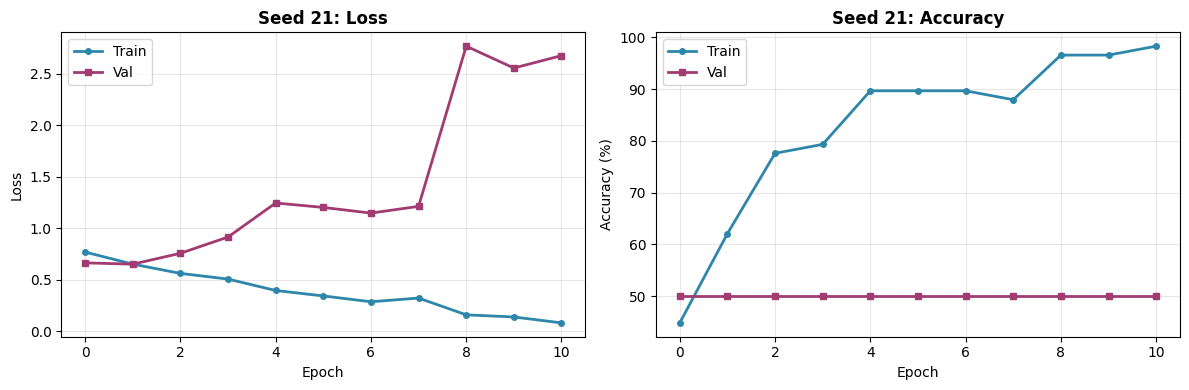

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42:
Val Acc=75.00%, F1=0.7500, Val Loss=0.5801
Control Acc=75.00%, Dementia Acc=75.00%
Early stop at: epoch 20 (best epoch: 10)


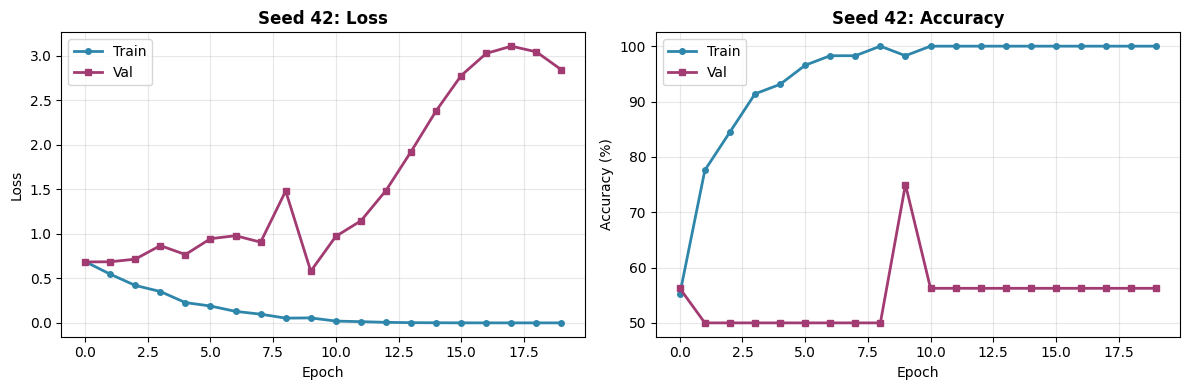

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84:
Val Acc=50.00%, F1=0.6667, Val Loss=0.6672
Control Acc=0.00%, Dementia Acc=100.00%
Early stop at: epoch 11 (best epoch: 1)


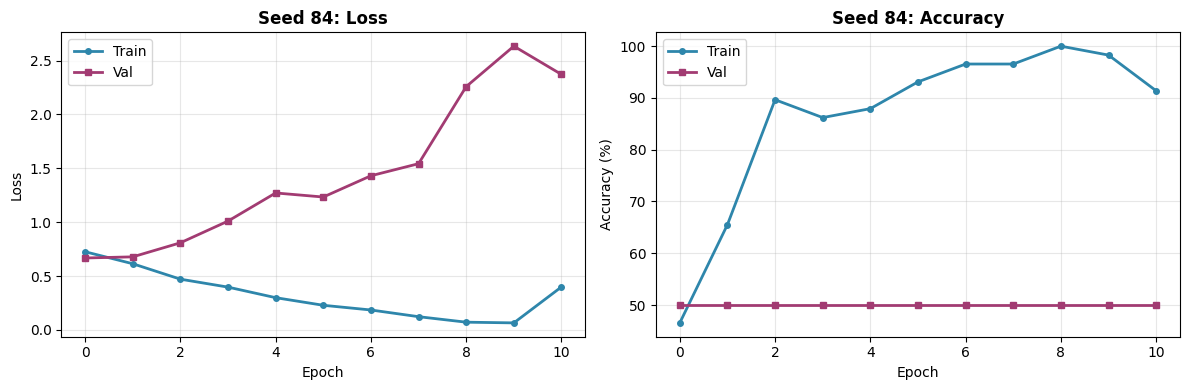

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168:
Val Acc=81.25%, F1=0.8235, Val Loss=0.5908
Control Acc=75.00%, Dementia Acc=87.50%
Early stop at: epoch 13 (best epoch: 3)


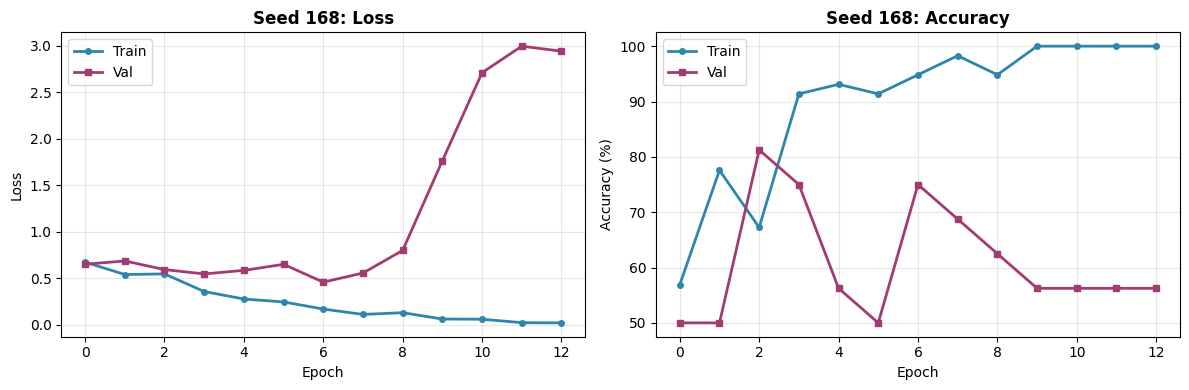

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336:
Val Acc=87.50%, F1=0.8889, Val Loss=0.4997
Control Acc=75.00%, Dementia Acc=100.00%
Early stop at: epoch 20 (best epoch: 10)


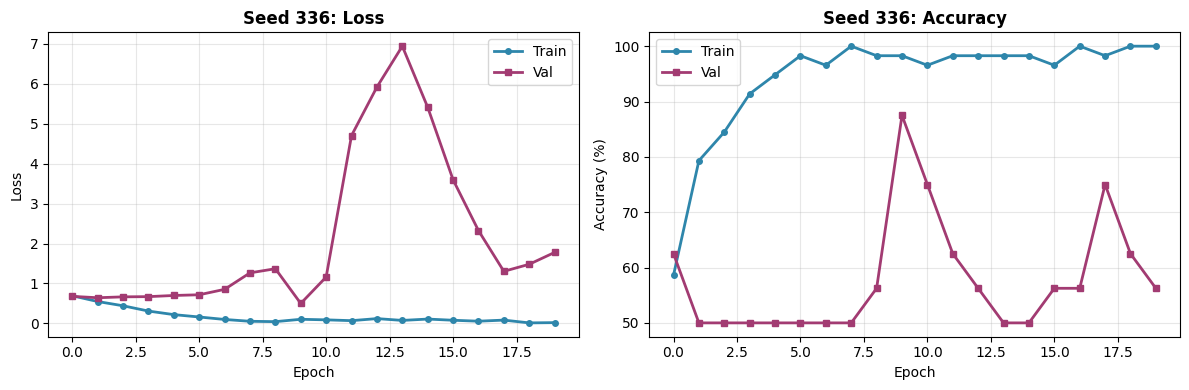

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")


Mean Validation Accuracy: 68.75% ± 17.68%
Mean Validation Loss: 0.6002 ± 0.0690
Mean Control Accuracy: 45.00% ± 41.08%
Mean Dementia Accuracy: 92.50% ± 11.18%
Mean F1 Score: 0.7592 ± 0.0977

Detailed Results:
Seed 21: Acc=50.00%, Loss=0.6631, Control Acc=0.00%, Dementia Acc=100.00%, F1=0.6667
Seed 42: Acc=75.00%, Loss=0.5801, Control Acc=75.00%, Dementia Acc=75.00%, F1=0.7500
Seed 84: Acc=50.00%, Loss=0.6672, Control Acc=0.00%, Dementia Acc=100.00%, F1=0.6667
Seed 168: Acc=81.25%, Loss=0.5908, Control Acc=75.00%, Dementia Acc=87.50%, F1=0.8235
Seed 336: Acc=87.50%, Loss=0.4997, Control Acc=75.00%, Dementia Acc=100.00%, F1=0.8889


## Step 7: Test Best Model on Multiple Datasets


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
else:
    best_idx = max_acc_indices[0]

# Get best model info
BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"

In [16]:
# Load the best model
from model import AD_XLSR_Model
from test import test_on_dataset

# Create model with XLSR configuration
test_model = AD_XLSR_Model()

# Load checkpoint (state_dict was saved directly)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
test_model.load_state_dict(checkpoint)
test_model = test_model.to(device)
test_model.eval()

AD_XLSR_Model(
  (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer1): Linear(in_features=1024, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer4): Linear(in_features=128, out_features=64, bias=True)
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer5): Linear(in_features=64, out_features=32, bias=True)
  (bn5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (pool_ad): PoolAttFF(
    (linear1): Linea

In [17]:
# Test on Pitt dataset (full dataset via Pitt-xlsr-test.csv)
pitt_results = test_on_dataset(
    dataset_name="Pitt",
    model=test_model,
    device=device,
    ssl_model=ssl_model,
    raw_audio_dir="data/raw/Pitt"
)


Testing on Pitt Dataset


============= Extracting XLSR features for Pitt Test Set =============
551 Audio Files


Extracting Pitt Test Set: 100%|██████████| 551/551 [00:00<00:00, 34132.26it/s]

Successfully extracted: 0
Already exists (skipped): 551
Errors: 0
Total: 551


Loading completed: 551 samples
Control: 242, Dementia: 309




Testing on Pitt: 100%|██████████| 18/18 [00:01<00:00, 12.88it/s]

Overall Accuracy: 50.64%, F1 Score: 0.5789
Control Accuracy: 38.02%, Dementia Accuracy: 60.52%


In [18]:
# Test on ADReSS dataset
adress_results = test_on_dataset(
    dataset_name="ADReSS",
    model=test_model,
    device=device,
    ssl_model=ssl_model,
    raw_audio_dir="data/raw/ADReSS"
)


Testing on ADReSS Dataset


============= Extracting XLSR features for ADReSS Test Set =============
156 Audio Files


Extracting ADReSS Test Set: 100%|██████████| 156/156 [00:00<00:00, 12667.93it/s]


Successfully extracted: 0
Already exists (skipped): 156
Errors: 0
Total: 156
Loading completed: 156 samples
Control: 78, Dementia: 78




Testing on ADReSS: 100%|██████████| 5/5 [00:00<00:00, 22.44it/s]

Overall Accuracy: 53.85%, F1 Score: 0.5955
Control Accuracy: 39.74%, Dementia Accuracy: 67.95%


In [19]:
# Test on Lu dataset
lu_results = test_on_dataset(
    dataset_name="Lu",
    model=test_model,
    device=device,
    ssl_model=ssl_model,
    raw_audio_dir="data/raw/Lu"
)


Testing on Lu Dataset


============= Extracting XLSR features for Lu Test Set =============
74 Audio Files


Extracting Lu Test Set: 100%|██████████| 74/74 [00:00<00:00, 15490.27it/s]


Successfully extracted: 0
Already exists (skipped): 74
Errors: 0
Total: 74
Loading completed: 74 samples
Control: 36, Dementia: 38




Testing on Lu: 100%|██████████| 3/3 [00:00<00:00, 27.96it/s]

Overall Accuracy: 68.92%, F1 Score: 0.7356
Control Accuracy: 52.78%, Dementia Accuracy: 84.21%


In [20]:
# Collect all test results
all_test_results = {
    'Pitt': pitt_results,
    'ADReSS': adress_results,
    'Lu': lu_results
}

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF ALL TEST RESULTS")
print("="*80)
print(f"{'Dataset':<20} {'Accuracy':<12} {'F1 Score':<12} {'Control Acc':<12} {'Dementia Acc':<12}")
print("-"*80)

for dataset_name, results in all_test_results.items():
    print(f"{dataset_name:<20} {results['accuracy']*100:>10.2f}%  {results['f1']:>10.4f}  "
          f"{results['control_acc']*100:>10.2f}%  {results['dementia_acc']*100:>10.2f}%")

print("="*80)


SUMMARY OF ALL TEST RESULTS
Dataset              Accuracy     F1 Score     Control Acc  Dementia Acc
--------------------------------------------------------------------------------
Pitt                      50.64%      0.5789       38.02%       60.52%
ADReSS                    53.85%      0.5955       39.74%       67.95%
Lu                        68.92%      0.7356       52.78%       84.21%


In [21]:
torch.cuda.empty_cache()